In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [5]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load the dataset freshly into this cell's memory
data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename("HousePrice")], axis=1)

# 2. Define our input features (X) and target variable (y)
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

# 3. Apply the standard feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Perform the 80/20 train-test validation split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Data successfully loaded, scaled, and split!")

Data successfully loaded, scaled, and split!


In [9]:
# Set up the dictionary of competing algorithms
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=5)
}

# Loop through, train, predict, and log performance results
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    # Calculate metrics cleanly without legacy warning arguments
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    
    results[name] = {
        "RMSE": rmse,
        "R2 Score": r2
    }

# Display results as a polished comparison dataframe
results_df = pd.DataFrame(results).T
results_df

,RMSE,R2 Score
Linear Regression,0.745581,0.575788
Ridge Regression,0.745554,0.575819
Decision Tree,0.724234,0.599732


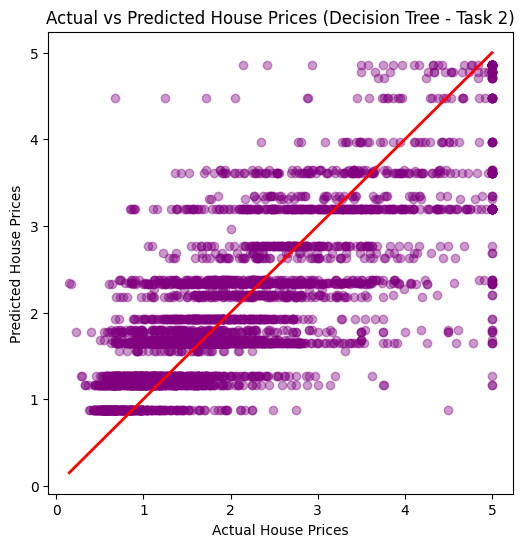

In [7]:
# Train the winning Decision Tree model to plot its predictions
best_model = DecisionTreeRegressor(max_depth=5)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

# Render the evaluation scatter plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.4, color="purple")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", lw=2)
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices (Decision Tree - Task 2)")
plt.show()

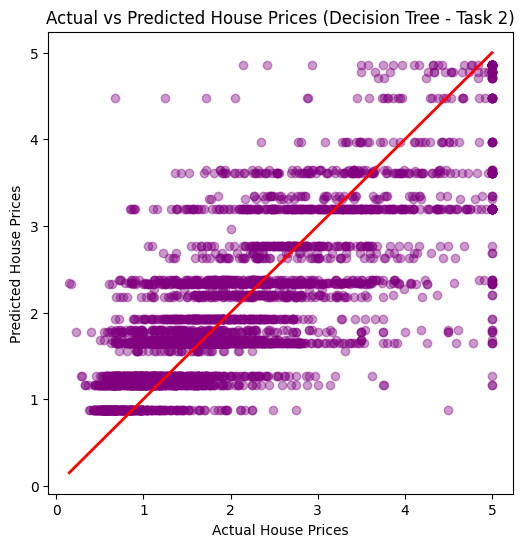

In [10]:
# 1. Re-import the plotting library just in case
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

# 2. Explicitly define and train your winning Task 2 model
best_model = DecisionTreeRegressor(max_depth=5)
best_model.fit(X_train, y_train)

# 3. Generate the predictions on your test data
y_pred = best_model.predict(X_test)

# 4. Render the evaluation distribution scatter plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.4, color="purple")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", lw=2)
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices (Decision Tree - Task 2)")
plt.show()